## LangChain day - 9 : Retrievers & RAG

### What are Retrievers
* A retriever is a component in LangChain that fetches relevant documents from a data source in response to a user's query.
* There are multiple types of retrievers, All retrievers in LangChain are runnables

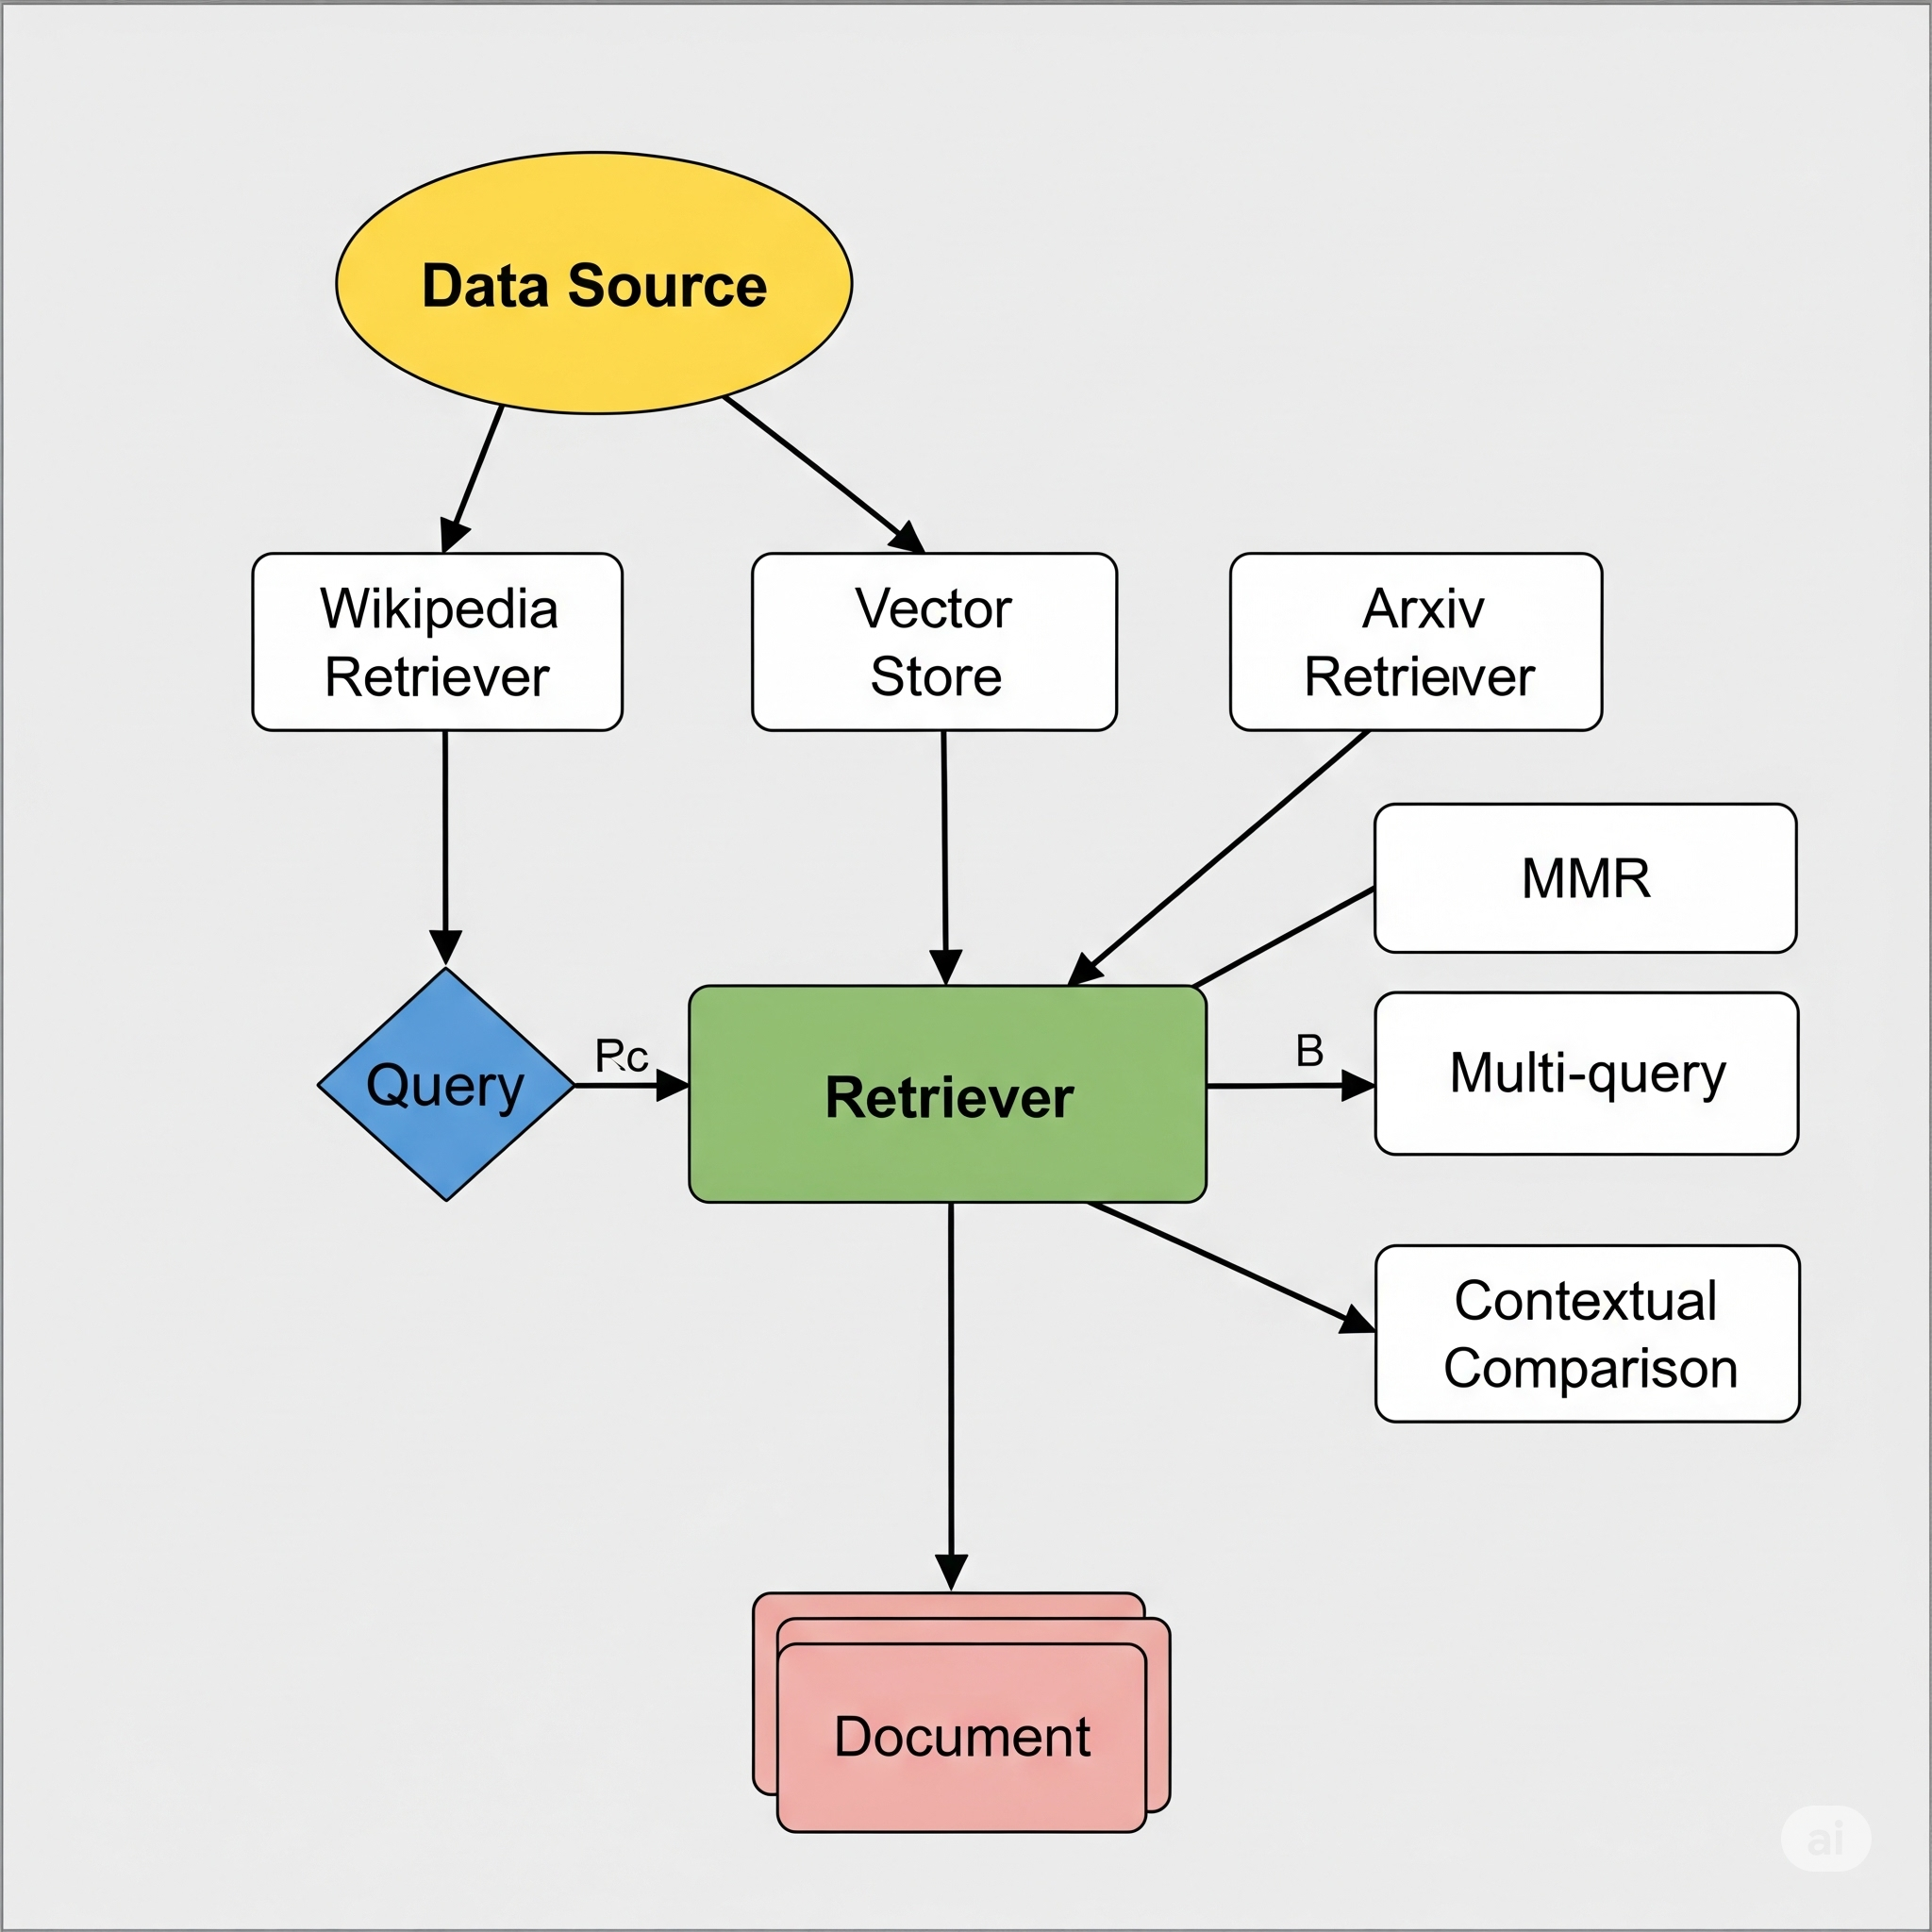

### Wikipedia Retriever

A Wikipedia Retriever is a retriever that queries the Wikipedia API to fetch relevant content for a given query.

**How It Works**
1.  You give it a query (e.g., “Albert Einstein”)
2.  It sends the query to Wikipedia’s API
3.  It retrieves the most relevant articles
4.  It returns them as LangChain Document objects

### Vector Store Retriever
A Vector Store Retriever in LangChain is the most common type of retriever that lets you search and fetch documents from a vector store based on **semantic similarity** using vector embeddings.

**How It Works**
1.  You store your documents in a **vector store** (like FAISS, Chroma, Weaviate)
2.  Each document is converted into a **dense vector** using an **embedding model**
3.  When the user enters a query:
    * It's also turned into a vector
    * The retriever compares the query vector with the stored vectors
    * It retrieves the top-k most similar ones

### Why MMR Retriever?
* In **regular similarity search**, you may get documents that are:
* All very similar to each other
* Repeating the same info
* Lacking diverse perspectives

MMR Retriever avoids that by:
* Picking the **most relevant document first**
* Then picking the next most relevant **and least similar** to already selected docs
* And so on…

This helps especially in RAG pipelines where:
* You want your context window to contain **diverse but still relevant information**
* Especially useful when documents are semantically overlapping

### Multi-Query Retriever
Sometimes a single query might not capture all the ways information is phrased in your documents.

For example:
**Query:**
* "How can I stay healthy?"

**Could mean:**
* What should I eat?
* How often should I exercise?
* How can I manage stress?

A simple similarity search might miss documents that talk about those things but don’t use the word “healthy.”

1.  Takes your original query
2.  Uses an LLM (e.g., GPT-3.5) to generate multiple semantically different versions of that query
3.  Performs retrieval for each sub-query
4.  Combines and deduplicates the results

In [1]:
from langchain_community.retrievers import WikipediaRetriever

In [2]:
# Initialize the retriever (optional: set language and top_k)
retriever = WikipediaRetriever(top_k_results=2, lang="en")

In [3]:
# Define your query
query = "the geopolitical history of india and pakistan from the perspective of a chinese"

# Get relevant Wikipedia documents
docs = retriever.invoke(query)

In [4]:
# Print retrieved content
for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Content:\n{doc.page_content}...")  # truncate for display


--- Result 1 ---
Content:
China and India maintained peaceful relations for thousands of years, but their relationship has varied since the Chinese Communist Party (CCP)'s victory in the Chinese Civil War in 1949 and the annexation of Tibet by the People's Republic of China. The two nations have sought economic cooperation with each other, while frequent border disputes and economic nationalism in both countries are major points of contention.
Cultural and economic relations between China and India date back to ancient times. The Silk Road not only served as a major trade route between India and China, but is also credited for facilitating the spread of Buddhism from India to East Asia. During the 19th century, China was involved in a growing opium trade with the East India Company, which exported opium grown in India. During World War II, both British India and the Republic of China (ROC) played a crucial role in halting the progress of Imperial Japan. After India became independent 

### Vector Store Retriever

In [5]:
from langchain_chroma import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from dotenv import load_dotenv
import os

In [6]:
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

In [7]:
# Step 1: Your source documents
documents = [
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Chroma is a vector database optimized for LLM-based search."),
    Document(page_content="Embeddings convert text into high-dimensional vectors."),
    Document(page_content="OpenAI provides powerful embedding models."),
]

In [8]:
# Step 2: Initialize embedding model
embedding_model = GoogleGenerativeAIEmbeddings(model='models/embedding-001', google_api_key=api_key)

# Step 3: Create Chroma vector store in memory
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="my_collection"
)

In [9]:
# Step 4: Convert vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [10]:
query = "What is Chroma used for?"
results = retriever.invoke(query)

In [11]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
Embeddings convert text into high-dimensional vectors.


In [12]:
results = vectorstore.similarity_search(query, k=2)

In [13]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
Embeddings convert text into high-dimensional vectors.


### MMR

In [14]:
# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]

In [15]:
from langchain_community.vectorstores import FAISS

# Initialize OpenAI embeddings
embedding_model = GoogleGenerativeAIEmbeddings(model='models/embedding-001', google_api_key=api_key)

# Step 2: Create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

In [16]:
# Enable MMR in the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",                   # <-- This enables MMR
    search_kwargs={"k": 3, "lambda_mult": 0.5}  # k = top results, lambda_mult = relevance-diversity balance
)

In [17]:
query = "What is langchain?"
results = retriever.invoke(query)

In [18]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
LangChain supports Chroma, FAISS, Pinecone, and more.

--- Result 2 ---
LangChain is used to build LLM based applications.

--- Result 3 ---
Embeddings are vector representations of text.


### Multiquery Retriever

In [19]:
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAI
from langchain.retrievers.multi_query import MultiQueryRetriever
from dotenv import load_dotenv
import os

In [20]:
load_dotenv()
api_key = os.getenv('GEMINI_API_KEY')
model = GoogleGenerativeAI(model="gemini-1.5-flash", google_api_key=api_key)

In [21]:
# Relevant health & wellness documents
all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

In [22]:
# Initialize OpenAI embeddings
embedding_model = GoogleGenerativeAIEmbeddings(model='models/embedding-001', google_api_key=api_key)

# Create FAISS vector store
vectorstore = FAISS.from_documents(documents=all_docs, embedding=embedding_model)

In [23]:
# Create retrievers
similarity_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [24]:
multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    llm=ChatGoogleGenerativeAI(model="gemini-1.5-flash", google_api_key=api_key)
)

In [25]:
# Query
query = "How to improve energy levels and maintain balance?"

In [26]:
# Retrieve results
similarity_results = similarity_retriever.invoke(query)
multiquery_results= multiquery_retriever.invoke(query)

In [27]:
for i, doc in enumerate(similarity_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

print("*"*150)

for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 3 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 4 ---
Deep sleep is crucial for cellular repair and emotional regulation.

--- Result 5 ---
Regular walking boosts heart health and can reduce symptoms of depression.
******************************************************************************************************************************************************

--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 3 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 4 ---
Regular walking boosts heart health and can reduce symptoms of

### ContextualCompressionRetriever

In [28]:
# Recreate the document objects from the previous data
docs = [
    Document(page_content=(
        """The Grand Canyon is one of the most visited natural wonders in the world.
        Photosynthesis is the process by which green plants convert sunlight into energy.
        Millions of tourists travel to see it every year. The rocks date back millions of years."""
    ), metadata={"source": "Doc1"}),

    Document(page_content=(
        """In medieval Europe, castles were built primarily for defense.
        The chlorophyll in plant cells captures sunlight during photosynthesis.
        Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
    ), metadata={"source": "Doc2"}),

    Document(page_content=(
        """Basketball was invented by Dr. James Naismith in the late 19th century.
        It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
    ), metadata={"source": "Doc3"}),

    Document(page_content=(
        """The history of cinema began in the late 1800s. Silent films were the earliest form.
        Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
        Modern filmmaking involves complex CGI and sound design."""
    ), metadata={"source": "Doc4"})
]

In [29]:
# Create a FAISS vector store from the documents
embedding_model = GoogleGenerativeAIEmbeddings(model='models/embedding-001', google_api_key=api_key)
vectorstore = FAISS.from_documents(docs, embedding_model)

In [30]:
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [31]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor

# Set up the compressor using an LLM
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", google_api_key = api_key)
compressor = LLMChainExtractor.from_llm(llm)

In [32]:
# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=base_retriever,
    base_compressor=compressor
)

In [33]:
# Query the retriever
query = "What is photosynthesis?"
compressed_results = compression_retriever.invoke(query)

In [34]:
for i, doc in enumerate(compressed_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Photosynthesis does not occur in animal cells.

--- Result 2 ---
Photosynthesis is the process by which green plants convert sunlight into energy.

--- Result 3 ---
The chlorophyll in plant cells captures sunlight during photosynthesis.
